# **🌾Seasonal Agricultural Performance Analysis**
### *A Data Analytics Project*

**Dataset:** Seasonal Agriculture Performance Dataset  
**Records:** 4,000 farms | 28 features  
**Seasons:** Kharif | Rabi | Zaid  
**Objective:** Analyze how agricultural performance
varies across seasons and identify meaningful patterns
in environmental conditions, resource usage, production
and economic outcomes.

---
**Tools Used:** Python | Pandas | Matplotlib | Seaborn  
**Author:** Harshit Saini

**Institution:** Engineering College Ajmer, Rajasthan

## 1. Data Loading and Preprocessing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [4]:
# Load dataset
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset (3).csv')
print(df.shape)                    # rows, columns
print(df.columns.tolist())         # column names
print(df.isnull().sum())           # Shows where ever the null values exits
print(df.dtypes)

(4000, 28)
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_k

In [5]:
# Dataset Statistical Overview
print("Dataset Shape:", df.shape)
print("\nBasic Statistics:")
df.describe().round(2)

Dataset Shape: (4000, 28)

Basic Statistics:


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.78,6.60,6.26,21.70,98.50,46.20,86.20,143.98,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.90,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


### 1.1 Data Cleaning & Imputation

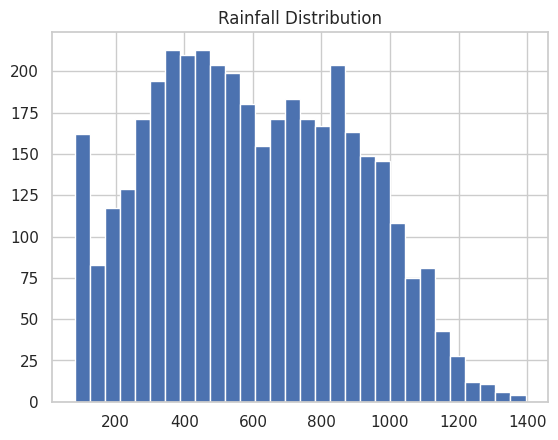

Skewness: 0.13954270661227788
Season
Kharif    1.95
Rabi      1.66
Zaid      1.45
Name: Yield_Tonnes_Ha, dtype: float64


In [6]:
df['Rainfall_mm'].hist(bins=30)
plt.title('Rainfall Distribution')
plt.show()

print("Skewness:", df['Rainfall_mm'].skew())

# Step 2: Season-wise yield median
print(df.groupby('Season')['Yield_Tonnes_Ha'].median())

In [7]:
# 1. Rainfall — simple median
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())

# 2. Soil Moisture — simple median
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())

# 3. Yield — grouped median (Season wise)
df['Yield_Tonnes_Ha'] = df.groupby('Season')['Yield_Tonnes_Ha'].transform(
    lambda x: x.fillna(x.median())
)

# 4. Verify
print(df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].isnull().sum())

Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


## Analytical Questions

**Q1.** The English translation of your query is: "How do Rainfall, Temperature, and Humidity vary across Kharif/Rabi/Zaid — and what is their impact on yield?"

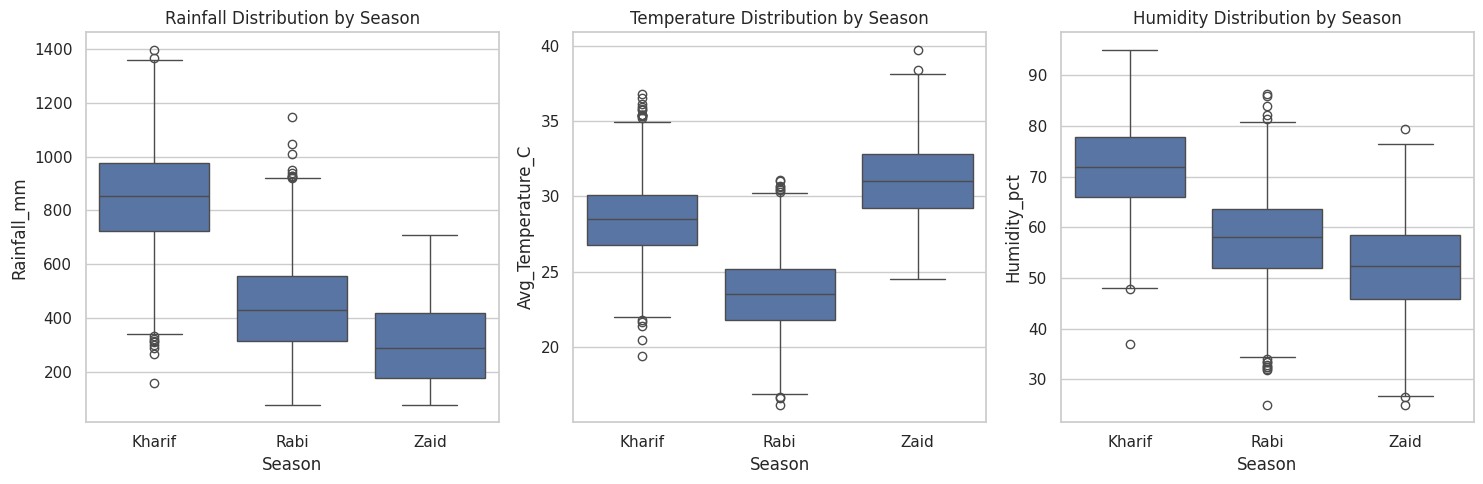

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1 — Rainfall
sns.boxplot(data=df, x='Season', y='Rainfall_mm', ax=axes[0])
axes[0].set_title('Rainfall Distribution by Season')

# Plot 2 — Temperature
sns.boxplot(data=df, x='Season', y='Avg_Temperature_C', ax=axes[1])
axes[1].set_title('Temperature Distribution by Season')

# Plot 3 — Humidity
sns.boxplot(data=df, x='Season', y='Humidity_pct', ax=axes[2])
axes[2].set_title('Humidity Distribution by Season')

plt.tight_layout()
plt.show()

## Solution 01 — Environmental Conditions Across Seasons

### Visualizations: Boxplots (Rainfall, Temperature, Humidity)

---

### Key Observations:

**Rainfall (mm):**

* **Highest Rainfall:** Kharif season recorded the highest rainfall (median ≈ 850 mm), which is significantly higher than Rabi (≈ 430 mm) and Zaid (≈ 290 mm).
* **Highest Variability:** Kharif also shows the widest spread (IQR: 720–980 mm), meaning rainfall is highly unpredictable during the monsoon season.
* **Extreme Weather Events:** Outliers are present in both Kharif and Rabi, indicating occasional extreme rainfall events.

**Temperature (°C):**

* **Hottest Season:** Zaid is the hottest season (median ≈ 31°C), reflecting typical summer farming conditions.
* **Most Consistent Temperature:** Zaid has the most consistent temperatures with minimal fluctuation (small box height = low IQR).
* **Most Variable Temperature:** Kharif experiences the highest temperature fluctuations.

**Humidity (%):**

* **Peak Humidity:** Kharif has the highest humidity (median ≈ 72%), which aligns directly with the monsoon season.
* **Unexpected Finding:** Even though Zaid is a dry summer season, it shows upper outliers reaching up to ≈ 80%, indicating occasional high-humidity days.

---

### Key Takeaway:

> Kharif is environmentally the most intense season, characterized by the highest rainfall, highest humidity, and maximum weather variation. In contrast, Zaid is consistently hot and dry. These distinct conditions directly guide crop selection and resource planning.

## 2. Economic Analysis Across Seasons

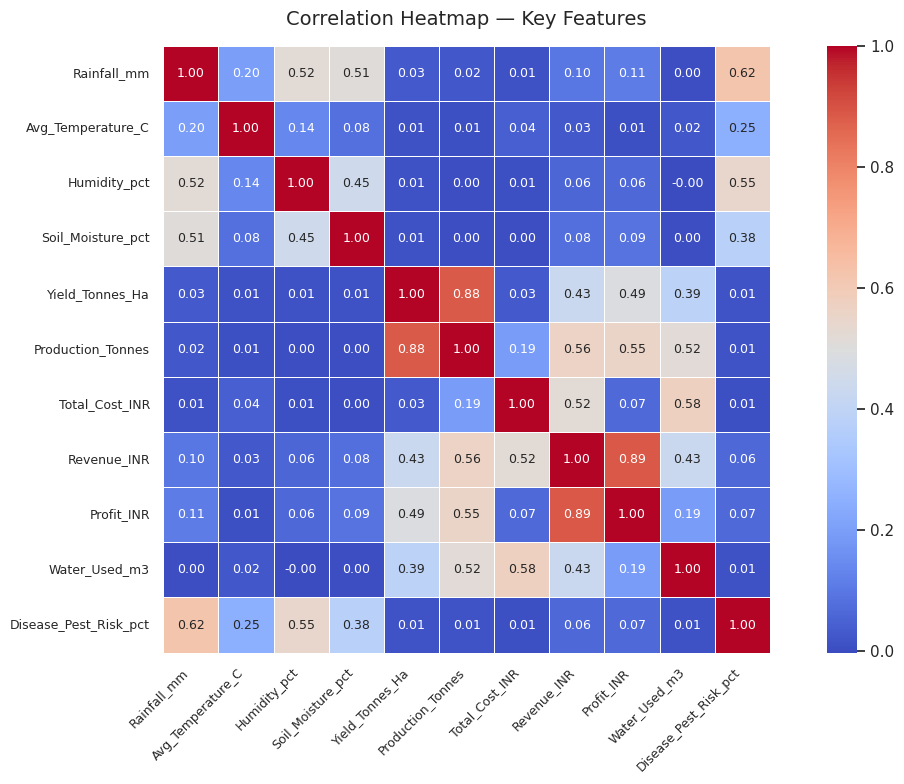

In [9]:
key_cols = ['Rainfall_mm', 'Avg_Temperature_C',
            'Humidity_pct', 'Soil_Moisture_pct',
            'Yield_Tonnes_Ha', 'Production_Tonnes',
            'Total_Cost_INR', 'Revenue_INR',
            'Profit_INR', 'Water_Used_m3',
            'Disease_Pest_Risk_pct']

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[key_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    annot_kws={'size': 9}
)
plt.title('Correlation Heatmap — Key Features',
          fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

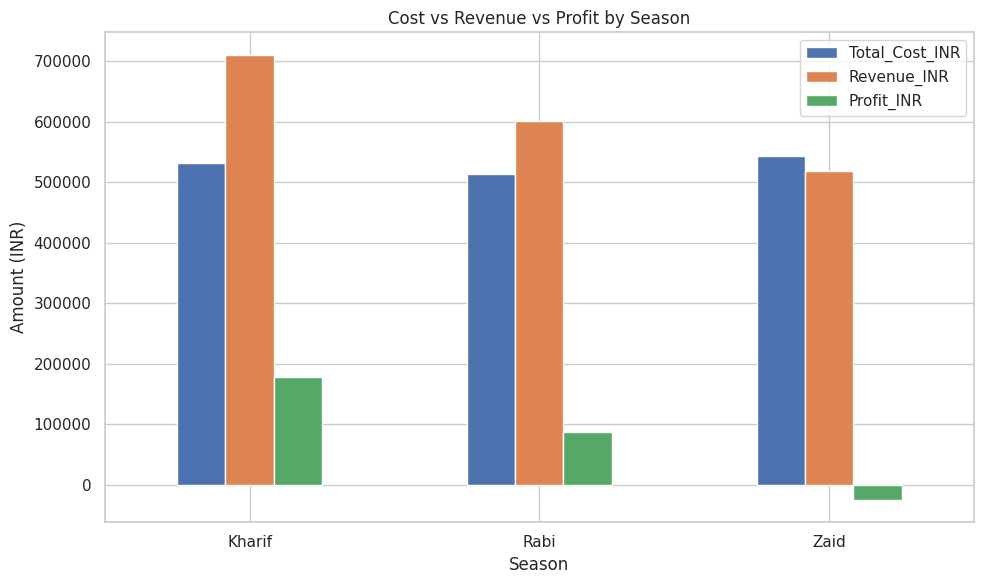

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

# Season-wise mean nikalo pehle
econ_data = df.groupby('Season')[
    ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR']
].mean().reset_index()

econ_data.plot(
    x='Season',
    y=['Total_Cost_INR','Revenue_INR','Profit_INR'],
    kind='bar',
    ax=ax
)

ax.set_title('Cost vs Revenue vs Profit by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Amount (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##**Key Findings:**
* Kharif is the Most Profitable
Season: Economically, Kharif generates the highest average revenue (≈ ₹705,000) and yields the best profit margins.


* Zaid is the Most Financial Risk-Prone Season: Zaid incurs the highest operational costs (≈ ₹550,000) and displays a negative median profit, highlighting a high risk of seasonal losses.

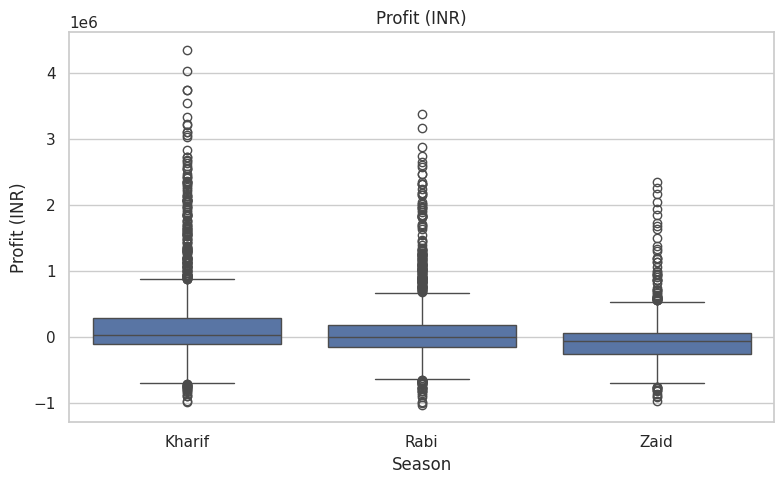

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Season', y='Profit_INR')
plt.title('Profit (INR)')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()

# **Key Findings:**

* Majority of Farms Just Break Even: Across all three seasons, median profit remains near zero, indicating that most farmers struggle to make significant net gains after covering production expenses.

* High Operating Expenses Eat Into Profits: Heavy investments in irrigation, fertilizers, and pesticides heavily offset total gross revenue.

* Profits are Heavily Skewed Toward Large Scale Farms: Substantial profits are confined to top-performing outlier farms, which likely benefit from economies of scale.

## 3. Resource Usage Across Seasons

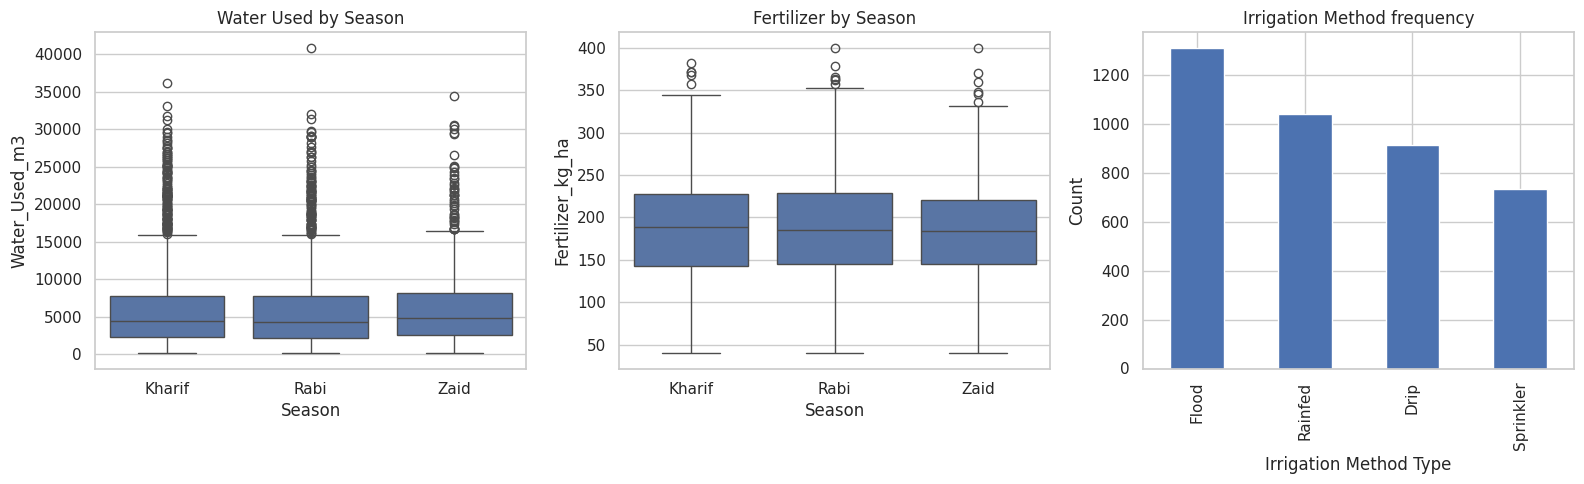

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — Water Used by Season
sns.boxplot(data=df, x='Season', y='Water_Used_m3',
            ax=axes[0])
axes[0].set_title('Water Used by Season')

# Plot 2 — Fertilizer by Season
sns.boxplot(data=df, x='Season', y='Fertilizer_kg_ha',
            ax=axes[1])
axes[1].set_title('Fertilizer by Season')

# Plot 3 — Irrigation Method frequency
irrigation_counts = df['Irrigation_Method'].value_counts()
irrigation_counts.plot(kind='bar', ax=axes[2])
axes[2].set_title('Irrigation Method frequency')
axes[2].set_xlabel('Irrigation Method Type')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [13]:
# Water efficiency by irrigation method
print(df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().round(2))

Irrigation_Method
Drip         6.27
Flood        3.44
Rainfed      7.56
Sprinkler    4.67
Name: Water_Efficiency_t_per_1000m3, dtype: float64


### Visualizations: Boxplots (Water, Fertilizer) + Bar Chart (Irrigation Methods)

---

### Key Observations:

**Water Usage:**
- The highest water consumption occurred in the Zaid season — consistent with high irrigation demand in summer months.

* The spread is also highest in Zaid — indicating variable water requirements across farms.

**Fertilizer Usage:**
- Rabi season observed the highest median fertilizer usage (≈ 230 kg/ha).

* Notable: Some farms are using more than 350-400 kg/ha of fertilizer — possible overuse indicating inefficient practices.
* Kharif has the highest median fertilizer profit — consistent with a high productivity season."

**Irrigation Methods:**
- Most popular: Flood (≈ 1300+ farms) — a traditional method, widely used due to low setup cost.
* Least used: Sprinkler (≈ 770 farms) — high setup cost, less accessible to small farmers.

**Water Efficiency by Irrigation Method:**
| Method    | Efficiency (t/1000m3) |
|-----------|----------------------|
| Rainfed   | 7.56 ✅ Highest      |
| Drip      | 6.27                 |
| Sprinkler | 4.67                 |
| Flood     | 3.44 ❌ Lowest       |

---

### Key Finding:
> Water usage is highest in the Zaid season — which is already the highest cost season, further explaining Zaid's poor profitability. Flood irrigation is the most popular method but also the most inefficient (3.44 t/1000m3). Rainfed farming shows the highest water efficiency but dependence on rainfall is a significant risk.

>Recommendation: Increasing drip irrigation adoption can significantly reduce water waste without compromising yield — especially in the Zaid season where water cost is already high.

## 4. Production Analysis

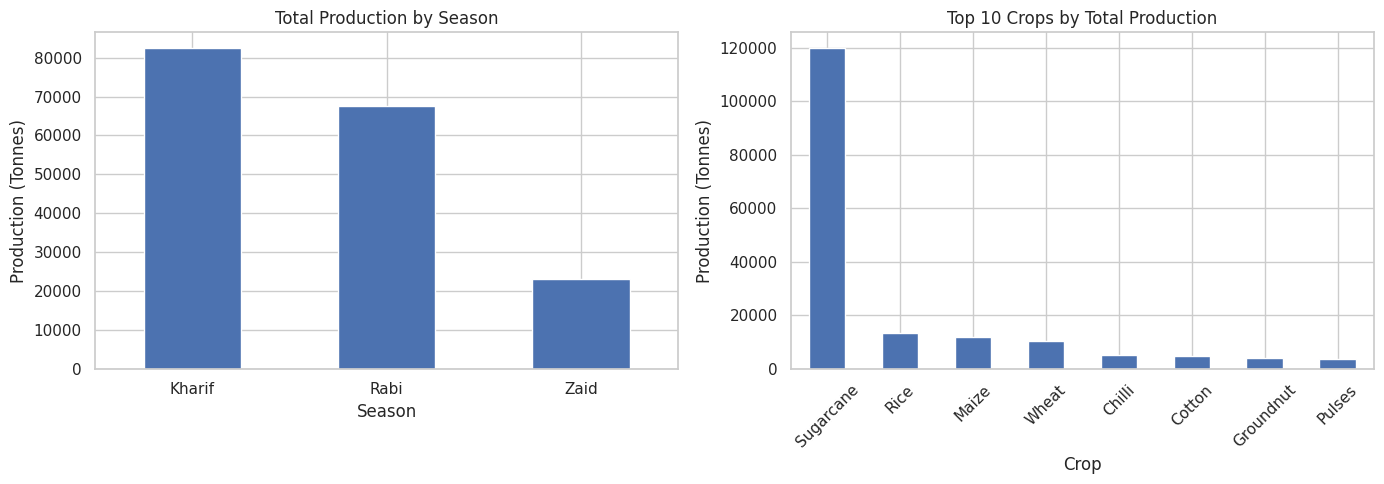

Top 5 States:
State
Punjab         25280.82
Gujarat        23586.01
Karnataka      23341.30
Maharashtra    22519.83
Telangana      20255.16
Name: Production_Tonnes, dtype: float64

Best Crop per Season:
Season
Kharif    (Kharif, Sugarcane)
Rabi        (Rabi, Sugarcane)
Zaid        (Zaid, Sugarcane)
Name: Production_Tonnes, dtype: object


In [14]:
# 1. Season-wise total production
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_prod = df.groupby('Season')['Production_Tonnes'].sum().reset_index()
season_prod.plot(kind='bar', x='Season',
                 y='Production_Tonnes', ax=axes[0],
                 legend=False)
axes[0].set_title('Total Production by Season')
axes[0].set_ylabel('Production (Tonnes)')
axes[0].tick_params(axis='x', rotation=0)

# 2. Top 10 crops by production
top_crops = df.groupby('Crop')['Production_Tonnes'].sum().nlargest(10)
top_crops.plot(kind='bar', ax=axes[1])
axes[1].set_title('Top 10 Crops by Total Production')
axes[1].set_ylabel('Production (Tonnes)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 3. Top producing states
print("Top 5 States:")
print(df.groupby('State')['Production_Tonnes'].sum().nlargest(5))

# 4. Best crop per season
print("\nBest Crop per Season:")
print(df.groupby(['Season','Crop'])['Production_Tonnes'].sum().groupby('Season').idxmax())

### Visualizations: Bar Charts (Season-wise Production + Top 10 Crops by Production)

---

### Key Observations:

**Season-wise Production:**
- Kharif season recorded the highest total production
  (approximately 82,000 tonnes), making it the most
  productive agricultural season.
- Rabi season ranked second with approximately
  68,000 tonnes of total production.
- Zaid season recorded significantly lower production
  (approximately 23,000 tonnes), consistent with its
  harsh summer conditions and higher resource costs.

**Top Crops by Total Production:**
- Sugarcane dominates overall production with
  approximately 1,20,000 tonnes — far exceeding
  all other crops combined.
- Rice (≈ 13,000 tonnes) and Maize (≈ 11,000 tonnes)
  ranked second and third respectively.
- Remaining crops including Wheat, Chilli, Cotton,
  Groundnut and Pulses contributed comparatively
  minimal production volumes.

**Best Performing Crop per Season:**
- Sugarcane recorded the highest production across
  all three seasons (Kharif, Rabi and Zaid),
  indicating its season-independent cultivation
  and high volume output nature.

**Top Producing States:**
| Rank | State       | Production (Tonnes) |
|------|-------------|---------------------|
| 1    | Punjab      | 25,280              |
| 2    | Gujarat     | 23,586              |
| 3    | Karnataka   | 23,341              |
| 4    | Maharashtra | 22,519              |
| 5    | Telangana   | 20,255              |

---

### Key Finding:
> Kharif season is the most productive season overall
> with 82,000 tonnes of total production. Sugarcane
> single-handedly dominates production charts across
> all three seasons, indicating its year-round
> cultivation viability and high volume nature.
> Punjab emerges as the highest producing state.
> Zaid season's significantly low production
> (23,000 tonnes) further supports Q2 findings —
> high resource costs combined with low output
> results in poor profitability during summer months.
>
> Notable Cross-Question Insight: Despite Sugarcane
> being the highest volume crop across all seasons,
> Q2 analysis revealed that majority farmers operate
> near break-even — suggesting that high production
> volume alone does not guarantee profitability in
> Indian agricultural context.

## 5. Disease & Pest Risk Analysis

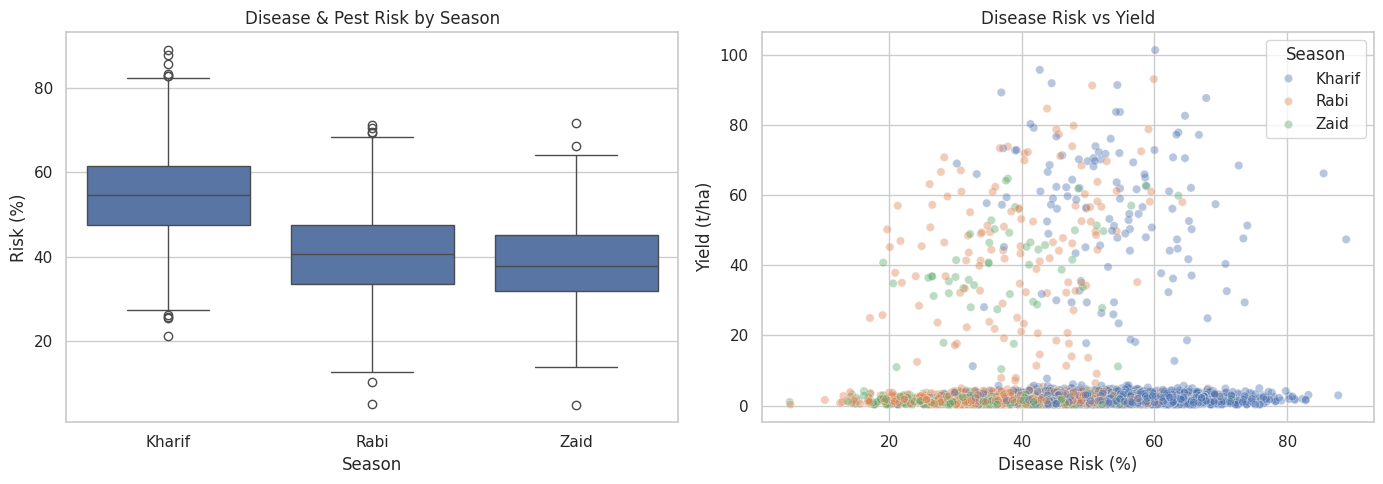

Correlation (Risk vs Yield): 0.014


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Risk by Season
sns.boxplot(data=df, x='Season',
            y='Disease_Pest_Risk_pct', ax=axes[0])
axes[0].set_title('Disease & Pest Risk by Season')
axes[0].set_ylabel('Risk (%)')

# Plot 2 — Risk vs Yield scatter
sns.scatterplot(data=df, x='Disease_Pest_Risk_pct',
                y='Yield_Tonnes_Ha',
                hue='Season', alpha=0.4, ax=axes[1])
axes[1].set_title('Disease Risk vs Yield')
axes[1].set_xlabel('Disease Risk (%)')
axes[1].set_ylabel('Yield (t/ha)')

plt.tight_layout()
plt.show()

# Correlation check
corr = df['Disease_Pest_Risk_pct'].corr(df['Yield_Tonnes_Ha'])
print(f"Correlation (Risk vs Yield): {corr:.3f}")

### **Visualizations: Boxplot (Risk by Season) + Scatter Plot (Disease Risk vs Yield)**

---

### **Key Observations:**

**Disease & Pest Risk by Season:**
- Kharif season recorded the highest disease and
  pest risk (median ≈ 53%), with a wide spread
  (IQR: 45%–63%), indicating highly variable and
  elevated risk conditions during monsoon months.
- Rabi and Zaid seasons showed comparatively lower
  and similar median risk levels (≈ 40% and 38%
  respectively), with wider spread in Rabi indicating
  occasional high-risk events.
- Kharif's elevated risk is consistent with its high
  humidity and rainfall conditions — creating favorable
  environment for disease and pest outbreaks.

**Disease Risk vs Yield (Scatter Plot):**
- No clear directional pattern is visible between
  disease risk and yield across any season.
- High yield values (60–100 t/ha) appear across
  varying levels of disease risk — suggesting that
  disease risk alone does not determine yield outcome.
- Majority of farms cluster near low yield values
  (0–10 t/ha) regardless of risk level.

**Correlation Analysis:**
- Correlation between Disease Risk and Yield = 0.014
- This is an extremely weak positive correlation —
  practically zero relationship between the two variables.

---

### **Key Finding:**
> Kharif season carries the highest disease and pest
> risk (median ≈ 53%), likely driven by its high
> humidity and rainfall creating favorable conditions
> for crop diseases and pest outbreaks.
>
> However, the correlation between Disease Risk and
> Yield is nearly zero (0.014), indicating that
> disease and pest risk does not significantly impact
> yield in this dataset. This is an unexpected finding
> — suggesting that farmers may be effectively managing
> disease risk through pesticide usage, or that other
> factors such as soil quality, irrigation and seed
> quality are stronger determinants of yield outcome.
>
> This finding highlights an important limitation:
> Disease_Pest_Risk_pct represents risk level, not
> actual disease occurrence — actual crop loss data
> would be needed for a more conclusive analysis.

## 6. Overall Correlation Analysis

## Conclusion — Seasonal Agricultural Analysis

### Overall Summary:
Analysis of 4,000 farms across Kharif, Rabi and Zaid
seasons revealed clear seasonal patterns in environmental
conditions, resource usage, production and economic
performance.

### Key Findings:
| Area | Finding |
|------|---------|
| Environment | Kharif — highest rainfall & humidity. Zaid — hottest & driest |
| Economics | Kharif most profitable. Zaid highest cost, lowest profit |
| Resources | Flood irrigation most used but least efficient |
| Production | Kharif highest output. Sugarcane dominates all seasons |
| Risk | Kharif highest disease risk but negligible yield impact |

### Critical Insight:
> Despite Kharif being the most productive and profitable
> season, majority farmers across all seasons operate
> near break-even — indicating thin profit margins in
> Indian agriculture regardless of season.

### Recommendations:
1. **Promote Drip Irrigation** — Especially in Zaid
   where water cost is highest. Drip system can
   significantly reduce water waste and overall cost.

2. **Shift Focus from Zaid Farming** — High cost and
   negative profit make Zaid economically unviable
   for small farmers. Resources better utilized in
   Kharif planning.

3. **Crop Diversification** — Over-dependence on
   Sugarcane carries market risk. Diversifying into
   Rice and Maize can stabilize farmer income across
   seasons.